# IEEE Fraud Detection — Data Understanding

In this notebook we perform initial data exploration and understanding
of the transaction and identity datasets.

Goal:
- Understand dataset structure
- Explore key features
- Identify missing values
- Analyze fraud distribution

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
trans = pd.read_csv('/content/train_transaction.csv')
ident = pd.read_csv('/content/train_identity.csv')

In [10]:
## Shape of the data
print(trans.shape)
print(ident.shape)

(154598, 394)
(144233, 41)


In [11]:
## first 5 rows
trans.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
ident.head()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


In [13]:
## dataset info
trans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 154598 entries, 0 to 154597
Columns: 394 entries, TransactionID to V339
dtypes: float64(376), int64(4), object(14)
memory usage: 464.7+ MB


The transaction dataset contains mostly numerical features.
It includes transaction amount, card information,
address information and engineered features (V1–V339).


### Key Transaction Features

TransactionID → unique transaction identifier  
TransactionDT → transaction timestamp  
TransactionAmt → transaction amount  
ProductCD → product category  
card1–card6 → card related information  
addr1, addr2 → address information  
V1–V339 → anonymized engineered features  
isFraud → target variable

In [18]:
## target column check

trans['isFraud'].value_counts()

,count
isFraud,
0,150462
1,4136


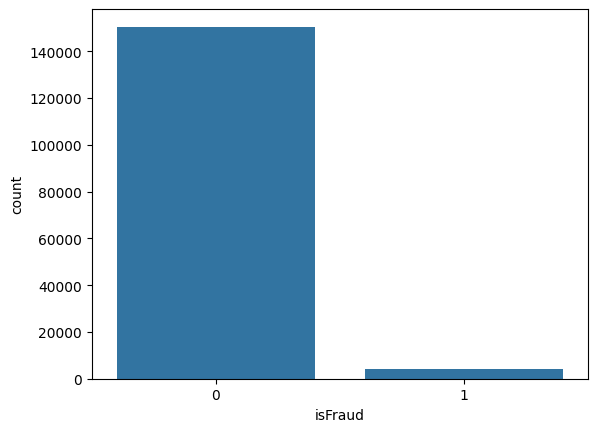

In [22]:

sns.countplot(x='isFraud', data = trans)
plt.show()

Dataset is highly imbalanced.
Fraud transactions are very rare.

In [30]:
trans['TransactionAmt'].describe().T

,TransactionAmt
count,154598.000000
mean,128.382836
std,201.096644
min,0.292000
25%,44.000000
50%,75.000000
75%,128.886250
max,5094.950000


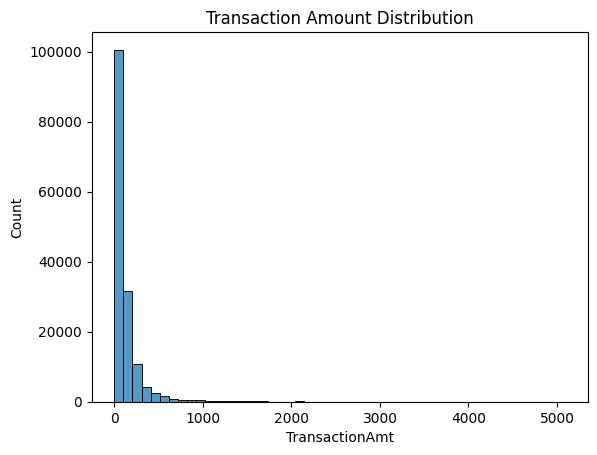

In [31]:
sns.histplot(trans['TransactionAmt'], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

majority transactions → low amount
few transactions → very high amount

In [25]:
# Missing Values

trans.isnull().sum().sort_values(ascending=False)

,0
D7,144390
dist2,141559
D13,138246
D12,136429
D14,136370
...,...
ProductCD,0
TransactionAmt,0
TransactionDT,0
isFraud,0


Many columns contain missing values.
Feature engineering will be required.

In [34]:
## identity data understanding
ident.shape

(144233, 41)

The identity dataset contains fewer records than the transaction dataset, indicating that identity information is not available for all transactions.

In [35]:
ident.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144233 entries, 0 to 144232
Data columns (total 41 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionID  144233 non-null  int64  
 1   id_01          144233 non-null  float64
 2   id_02          140872 non-null  float64
 3   id_03          66324 non-null   float64
 4   id_04          66324 non-null   float64
 5   id_05          136865 non-null  float64
 6   id_06          136865 non-null  float64
 7   id_07          5155 non-null    float64
 8   id_08          5155 non-null    float64
 9   id_09          74926 non-null   float64
 10  id_10          74926 non-null   float64
 11  id_11          140978 non-null  float64
 12  id_12          144233 non-null  object 
 13  id_13          127320 non-null  float64
 14  id_14          80044 non-null   float64
 15  id_15          140985 non-null  object 
 16  id_16          129340 non-null  object 
 17  id_17          139369 non-nul

In [37]:
ident.isnull().sum().sort_values(ascending=False).head(20)

,0
id_24,139486
id_25,139101
id_07,139078
id_08,139078
id_21,139074
id_26,139070
id_23,139064
id_27,139064
id_22,139064
id_18,99120


Many identity features contain missing values.

In [39]:
ident['DeviceType'].value_counts()

,count
DeviceType,
desktop,85165
mobile,55645


Most transactions originate from dekstop

In [40]:
ident['DeviceInfo'].value_counts().head(10)

,count
DeviceInfo,
Windows,47722
iOS Device,19782
MacOS,12573
Trident/7.0,7440
rv:11.0,1901
rv:57.0,962
SM-J700M Build/MMB29K,549
SM-G610M Build/MMB29K,461
SM-G531H Build/LMY48B,410


Key Observations

1. Identity dataset contains device and identity related features.
2. Not all transactions have associated identity information.
3. The dataset contains anonymized identity variables (id_01 – id_38).
4. DeviceType and DeviceInfo provide device-related information.
5. Many identity features contain missing values.